## Vertical cross-section to show rh and winds `xarray` and `matplotlib` (Use environment `NPL 2025b`)

This notebook shows how to do a vertical cross-section from any MPAS mesh. Make sure you use the environment `NPL 2025b`

In [1]:
import numpy as np
import xarray as xr
import uxarray as ux
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
from scipy.interpolate import LinearNDInterpolator
from scipy.ndimage import gaussian_filter
import glob

Function for quick vertical interpolation from model levels to pressure levels.

In [2]:
def interp_vertical(var_line,pres_line,target_p):
    """Interpolates 2D line data vertically onto standard pressure levels."""
    n_pts = var_line.shape[0]
    n_p = len(target_p)
    result = np.zeros((n_p,n_pts))
    
    for i in range(n_pts):
        # Reverse profiles so pressure increases
        p_prof = pres_line[i,::-1]
        v_prof = var_line[i,::-1]
        # Log-linear pressure interpolation
        result[:,i] = np.interp(np.log(target_p[::-1]),np.log(p_prof),v_prof)[::-1]
        
    return result

Set base path and read in history file and static file.

In [3]:
base_path = "../240-48km_variable/"
static_path = f"{base_path}SouthAmerica.static.nc"
data_path = f"{base_path}history.2014-09-13_00.00.00.nc"

ds_stat = xr.open_dataset(static_path,decode_times=False).squeeze()
ds_data = xr.open_dataset(data_path).squeeze()

Here we define our cross-section line. There are a few options here. We will start with a zonal cross-section across S. America at 31 S.

In [4]:
# Define cross-section line
lat_start, lon_start = -31.0, 285.0 # Across South America along 31 S
lat_end, lon_end = -31.0, 315.0
#lat_start, lon_start = 45.0, 236.0 # NW to SE CONUS
#lat_end, lon_end = 28.0, 278.0
#lat_start, lon_start = 32.0, 242.0 # SW to NE CONUS
#lat_end, lon_end = 45.0, 291.0
n_pt = 500  # Number of points along the line

# Pressure levels
p_1d = np.arange(1000,50,-25)
n_p = len(p_1d)

Reading in the 3D variables we care about. rh, and winds.

In [5]:
relhum = ds_data["relhum"].values
uwind = ds_data["uReconstructZonal"].values
vwind = ds_data["uReconstructMeridional"].values
pres = ds_data["pressure"].values * 0.01
wind = np.sqrt(uwind**2+vwind**2)

Create 500 (or whatever n_pt is) evenly spaced points along the cross-section. It then uses MPAS cell centers to construct a 2D Delauney triangulation to spatially interpolate along the line.

In [6]:
lon_1d = np.linspace(lon_start,lon_end,n_pt)
lat_1d = np.linspace(lat_start,lat_end,n_pt)
line_points = np.column_stack((lon_1d,lat_1d))

# MPAS grid triangulation
mpas_lons = np.degrees(ds_stat["lonCell"].values)
mpas_lats = np.degrees(ds_stat["latCell"].values)
tri = Delaunay(np.column_stack((mpas_lons,mpas_lats)))

Here, we interpolate our 3D model-level data from the unstructured MPAS mesh onto the cross-section path. It then vertically interpolates to pressure levels using the `interp_vertical` function we created at the top.

In [7]:
# Interpolate winds and mflux
n_levels = pres.shape[1]

pres_line = np.zeros((n_pt,n_levels))
relhum_line = np.zeros((n_pt,n_levels))
uwind_line = np.zeros((n_pt,n_levels))
vwind_line = np.zeros((n_pt,n_levels))
wind_line = np.zeros((n_pt,n_levels))

for k in range(n_levels):
    pres_line[:,k]  = LinearNDInterpolator(tri,pres[:,k])(line_points)
    relhum_line[:,k] = LinearNDInterpolator(tri,relhum[:,k])(line_points)
    uwind_line[:,k] = LinearNDInterpolator(tri,uwind[:,k])(line_points)
    vwind_line[:,k] = LinearNDInterpolator(tri,vwind[:,k])(line_points)
    wind_line[:,k] = LinearNDInterpolator(tri,wind[:,k])(line_points)

rh_cross_section = np.clip(interp_vertical(relhum_line,pres_line,p_1d),0,100)
uu_cross_section = interp_vertical(uwind_line,pres_line,p_1d)
vv_cross_section = interp_vertical(vwind_line,pres_line,p_1d)
uv_cross_section = gaussian_filter(interp_vertical(wind_line,pres_line,p_1d),sigma=0.8)

Now, interpolate terrain along that line and interpolate to pressure level so we can see the mountains.

In [8]:
# Terrain/pressure interpolation needed to plot terrain
ter = ds_stat["ter"].squeeze().values
terrain_line = LinearNDInterpolator(tri,ter)(line_points)
terrain_pressure = 1000*np.exp(-9.81*terrain_line/(287.0*280.0))

Finally, we make the plot. This is all fairly basic matplotlib contours and barbs/quivers with a log scale on the Y-axis.

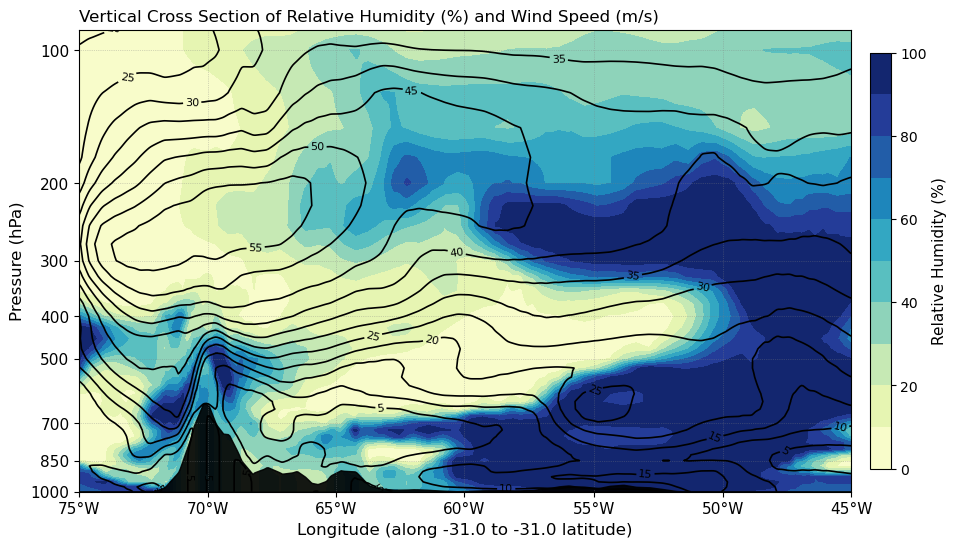

In [9]:
fig, ax = plt.subplots(figsize=(12,6))

# Make rh contour plot
levels = np.linspace(0, 100, 11)
cs = ax.contourf(np.arange(n_pt), p_1d, rh_cross_section, levels=levels, cmap="YlGnBu", extend="neither")
cbar = plt.colorbar(cs,ax=ax,shrink=0.9,pad=0.02)
cbar.set_label("Relative Humidity (%)",fontsize=11)

# Draw v wind contour lines to show LLJ
uv_levels = np.arange(0, 70, 5)
lines = ax.contour(np.arange(n_pt),p_1d,uv_cross_section,levels=uv_levels,colors="black",linewidths=1.2)
ax.clabel(lines,fmt="%d",fontsize=8,inline=True,inline_spacing=2)

# Plot terrain as a fill
ax.fill_between(np.arange(n_pt),p_1d.max(),terrain_pressure,color="black",alpha=0.9)

# Label lons
lon_1d_180 = np.where(lon_1d>180,lon_1d-360,lon_1d)
target_lons = np.arange(np.ceil(lon_1d_180.min()/5)*5,lon_1d_180.max()+0.01,5)
ax.set_xticks([np.abs(lon_1d_180 - l).argmin() for l in target_lons])
ax.set_xticklabels([f"{abs(int(l))}°W" for l in target_lons], fontsize=11)
ax.set_xlabel(f"Longitude (along {lat_start} to {lat_end} latitude)",fontsize=12)

# Format Y-axis and add labels
ax.set_yscale("log")
ax.set_ylim(1000,90)
ax.set_yticks(ticks := [1000, 850, 700, 500, 400, 300, 200, 100],labels=ticks,fontsize=11)
ax.tick_params(axis="y", which="minor", left=False, right=False)
ax.set_ylabel("Pressure (hPa)",fontsize=12)
ax.grid(True, linestyle=":", linewidth=0.5, color="gray", alpha=0.6)

# Title and save fig
plt.title("Vertical Cross Section of Relative Humidity (%) and Wind Speed (m/s)",loc="left",fontsize=12)
#plt.savefig("xsec_rh.jpg", bbox_inches="tight", dpi=300)
plt.show()